# Weighted graphs для 368 Xela-сенсоров

Ноутбук строит четыре типа sensor-level графов по 3D координатам сенсоров: physical, distance threshold, pad-local/outer kNN и custom. Вес каждого ребра равен евклидову расстоянию между двумя сенсорами в метрах.

In [21]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from omegaconf import OmegaConf

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **_: x

repo_root = Path.cwd()
if repo_root.name == "graph_visualizations":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from tactile_ssl.data.xela_tactile import XelaSSLDataset
from tactile_ssl.data.xela.utils import XELA_FLATTEN_ORDER
from tactile_ssl.graph.builders import (
    build_custom_graph,
    build_distance_threshold_graph,
    build_knn_graph,
    build_physical_graph,
    build_sensor_graph,
    pairwise_sensor_distances,
)
from tactile_ssl.graph.stats import sensor_graph_stats
from tactile_ssl.graph.utils import SENSOR_TO_HAND_PART, validate_against_xela_flatten_order
from tactile_ssl.graph.vis_utils import plot_sensor_graph_comparison

validate_against_xela_flatten_order(XELA_FLATTEN_ORDER)


## Параметры

In [ ]:
DATA_ROOT_OVERRIDE = None  # например: "/path/to/sparsh-skin-dataset"
LOCAL_DATASET_CANDIDATE = repo_root / "facebook--sparsh-skin-dataset"
SEQUENCE_NAME = "drill"
SEQUENCE_ID = 0

DISTANCE_THRESHOLD = 0.02  # meters
K_INNER_NEIGHBORS = 6
K_OUTER_NEIGHBORS = 0
BRIDGE_K = 1
CUSTOM_LINK_PADS = "dense"  # none | sparse | dense
CUSTOM_PHYS_BRIDGE_K = 4
CUSTOM_DISTANCE_THRESHOLD = 0.025
CUSTOM_K_INNER_NEIGHBORS = 0
CUSTOM_K_OUTER_NEIGHBORS = 0
CUSTOM_OUTER_EDGE_DISTANCE = None
NUM_VIS_WINDOWS = 10
FRAME_IN_WINDOW = 0

DISTANCE_SWEEP_WINDOW_ID = 527
DISTANCE_SWEEP_STEP_MULTIPLIER = 0.5
DISTANCE_SWEEP_MAX_MULTIPLIER = 10.0
K_SWEEP_WINDOW_ID = 527
K_SWEEP_MIN = 1
K_SWEEP_MAX = 12

print(f"Distance threshold: {DISTANCE_THRESHOLD:.3f} m = {DISTANCE_THRESHOLD * 100:.1f} cm")
print(f"k inner neighbors: {K_INNER_NEIGHBORS}")
print(f"k outer neighbors: {K_OUTER_NEIGHBORS}")
print(f"physical bridge_k: {BRIDGE_K}")
print(
    "custom: "
    f"link_pads={CUSTOM_LINK_PADS}, "
    f"phys_bridge_k={CUSTOM_PHYS_BRIDGE_K}, "
    f"distance_threshold={CUSTOM_DISTANCE_THRESHOLD}, "
    f"k_inner_neighbors={CUSTOM_K_INNER_NEIGHBORS}, "
    f"k_outer_neighbors={CUSTOM_K_OUTER_NEIGHBORS}, "
    f"outer_edge_distance={CUSTOM_OUTER_EDGE_DISTANCE}"
)


## Загрузка последовательности

In [23]:
paths_cfg = OmegaConf.load(repo_root / "config" / "paths" / "default.yaml")
data_cfg = OmegaConf.load(repo_root / "config" / "data" / "xela.yaml")

if DATA_ROOT_OVERRIDE is not None:
    data_root = Path(DATA_ROOT_OVERRIDE).expanduser()
elif (LOCAL_DATASET_CANDIDATE / "xela" / "pretraining" / "extracted").exists():
    data_root = LOCAL_DATASET_CANDIDATE
else:
    data_root = Path(paths_cfg.data_root).expanduser()

extracted_root = data_root / "xela" / "pretraining" / "extracted"
sequence_path = extracted_root / SEQUENCE_NAME / str(SEQUENCE_ID)
baseline_signal_path = extracted_root / "baseline" / "xela" / "data.pkl"
urdf_path = extracted_root / "urdf" / "ahrcpcpn.urdf"

missing = [path for path in (sequence_path, baseline_signal_path, urdf_path) if not path.exists()]
if missing:
    missing_lines = "\n".join(f"- {path}" for path in missing)
    raise FileNotFoundError(
        "Не найдены файлы датасета для графовой визуализации. "
        "Переопределите DATA_ROOT_OVERRIDE на локальный корень sparsh-skin-dataset.\n"
        f"Проверенные пути:\n{missing_lines}"
    )

dataset_config = OmegaConf.create(
    {
        "window_time": data_cfg.window_time,
        "window_overlap": data_cfg.window_overlap,
        "interpolating_freq": data_cfg.interpolating_freq,
        "subtract_baseline": True,
        "smooth_data": False,
        "bias_noise_std": 0.0,
        "bias_range": 0.0,
        "cache": {"enabled": False, "root": str(repo_root / ".cache" / "xela_artifacts")},
        "preprocessing": data_cfg.preprocessing,
        "features": {"use_spatial_coords": False},
    }
)

dataset = XelaSSLDataset(
    config=dataset_config,
    data_path=str(sequence_path),
    xela_urdf_path=str(urdf_path),
    baseline_signal_path=str(baseline_signal_path),
    load_images=False,
)

print(f"data_root: {data_root}")
print(f"sequence_path: {sequence_path}")
print(f"windows: {len(dataset)}")
print(f"frames per window: {dataset.num_frames_per_window}")


data_root: /workspace-SR004.nfs2/kovtun/tactile/sparsh-skin-dataset
sequence_path: /workspace-SR004.nfs2/kovtun/tactile/sparsh-skin-dataset/xela/pretraining/extracted/drill/0
windows: 1187
frames per window: 10


## Helpers

In [ ]:
GRAPH_TYPES = ("physical", "distance_threshold", "knn", "custom")

def get_window_positions(window_id, frame_in_window=FRAME_IN_WINDOW):
    sample = dataset[window_id]
    frame_idx = min(frame_in_window, sample["sensor_poses"].shape[0] - 1)
    return sample["sensor_poses"][frame_idx, :, :3].detach().cpu().numpy()

def build_graph_by_type(graph_type, positions):
    if graph_type == "physical":
        return build_physical_graph(positions, bridge_k=BRIDGE_K)
    if graph_type == "distance_threshold":
        return build_distance_threshold_graph(positions, threshold=DISTANCE_THRESHOLD)
    if graph_type == "knn":
        return build_knn_graph(
            positions,
            k_inner_neighbors=K_INNER_NEIGHBORS,
            k_outer_neighbors=K_OUTER_NEIGHBORS,
            symmetrize=True,
        )
    if graph_type == "custom":
        return build_custom_graph(
            positions,
            link_pads=CUSTOM_LINK_PADS,
            phys_bridge_k=CUSTOM_PHYS_BRIDGE_K,
            distance_threshold=CUSTOM_DISTANCE_THRESHOLD,
            k_inner_neighbors=CUSTOM_K_INNER_NEIGHBORS,
            k_outer_neighbors=CUSTOM_K_OUTER_NEIGHBORS,
            outer_edge_distance=CUSTOM_OUTER_EDGE_DISTANCE,
        )
    return build_sensor_graph(positions, graph_type)

def window_ids_for_visualization(num_windows=NUM_VIS_WINDOWS):
    if len(dataset) <= num_windows:
        return list(range(len(dataset)))
    return sorted(set(np.linspace(0, len(dataset) - 1, num_windows, dtype=int).tolist()))

VIS_WINDOW_IDS = window_ids_for_visualization()
VIS_POSITIONS = {window_id: get_window_positions(window_id) for window_id in VIS_WINDOW_IDS}
print(VIS_WINDOW_IDS)


## Метрики по всему датасету

In [25]:
rows = []
for window_id in tqdm(range(len(dataset)), desc="Graph metrics"):
    positions = get_window_positions(window_id)
    for graph_type in GRAPH_TYPES:
        graph = build_graph_by_type(graph_type, positions)
        row = sensor_graph_stats(graph)
        row["window_id"] = window_id
        row["graph_type"] = graph_type
        rows.append(row)

metrics_df = pd.DataFrame(rows)
summary_df = metrics_df.groupby("graph_type").mean(numeric_only=True)
summary_df


Graph metrics:   0%|          | 0/1187 [00:00<?, ?it/s]

,num_nodes,num_edges,avg_degree,min_degree,max_degree,num_components,largest_component,min_edge_weight,mean_edge_weight,max_edge_weight,window_id
graph_type,,,,,,,,,,,
custom,368.0,5037.296546,27.376612,15.0,51.534120,1.000000,368.000000,0.004840,0.017620,0.056154,593.0
distance_threshold,368.0,3146.459983,17.100326,7.0,31.524853,4.376580,209.666386,0.004840,0.012925,0.019970,593.0
knn,368.0,1310.781803,7.123814,6.0,10.209773,10.486099,104.643639,0.004840,0.008812,0.018196,593.0
physical,368.0,587.000000,3.190217,2.0,4.252738,1.000000,368.000000,0.005143,0.006909,0.052293,593.0


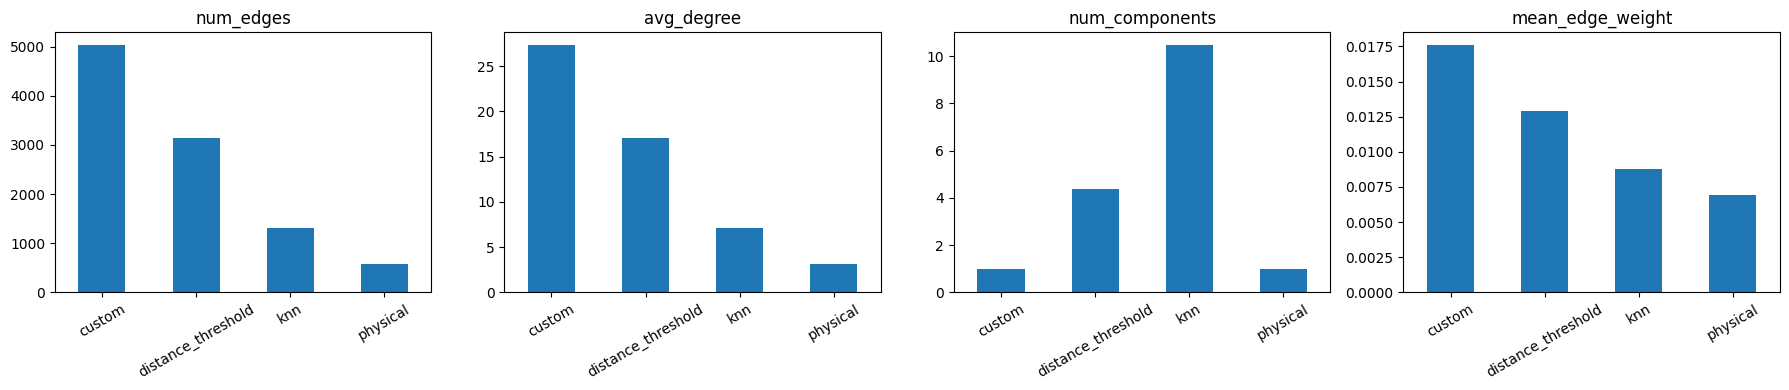

In [26]:
metrics_to_plot = ["num_edges", "avg_degree", "num_components", "mean_edge_weight"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4.5 * len(metrics_to_plot), 4))
for ax, metric in zip(axes, metrics_to_plot):
    summary_df[metric].plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## Physical graph: 10 временных окон

window=0 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 4, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.005166663322597742, 'mean_edge_weight': 0.006898767780512571, 'max_edge_weight': 0.048860687762498856}


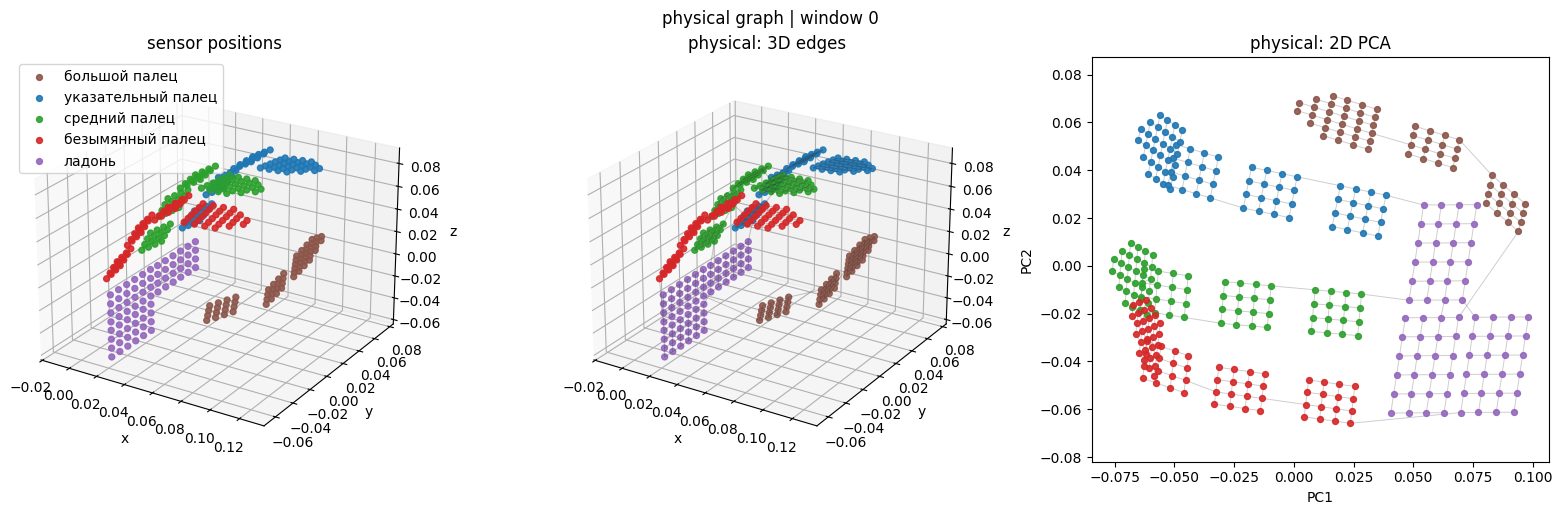

window=131 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 4, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.00516665680333972, 'mean_edge_weight': 0.006989776156842709, 'max_edge_weight': 0.058677878230810165}


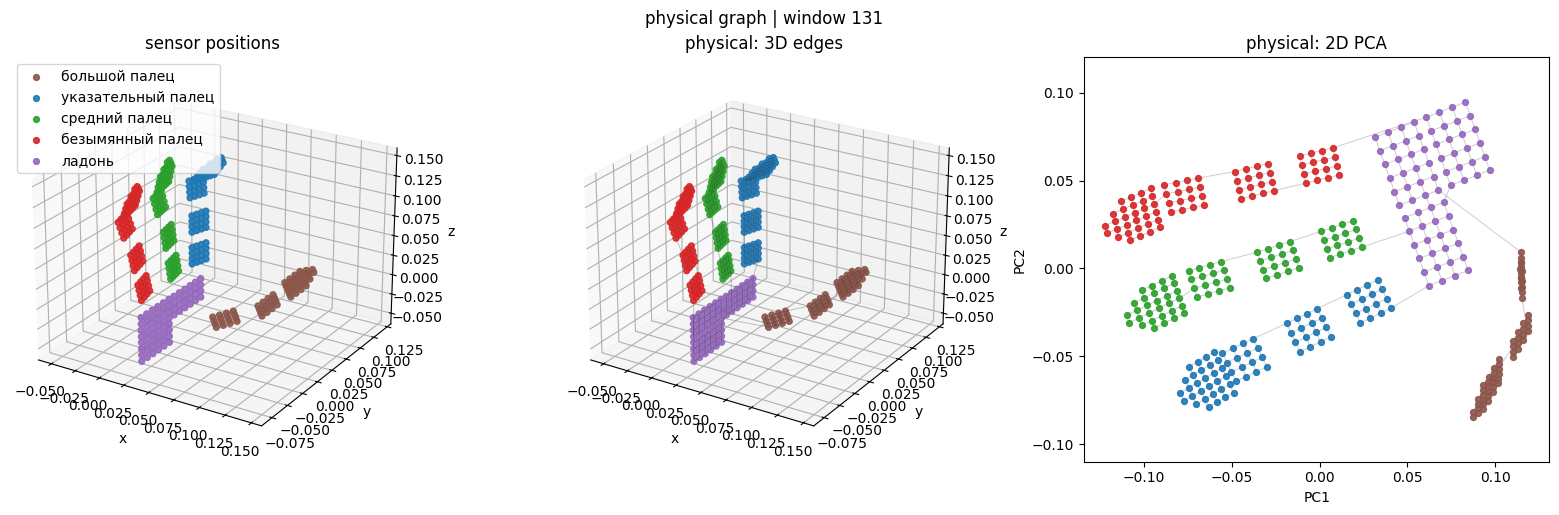

window=263 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 4, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.005166663788259029, 'mean_edge_weight': 0.006867909338325262, 'max_edge_weight': 0.043518777936697006}


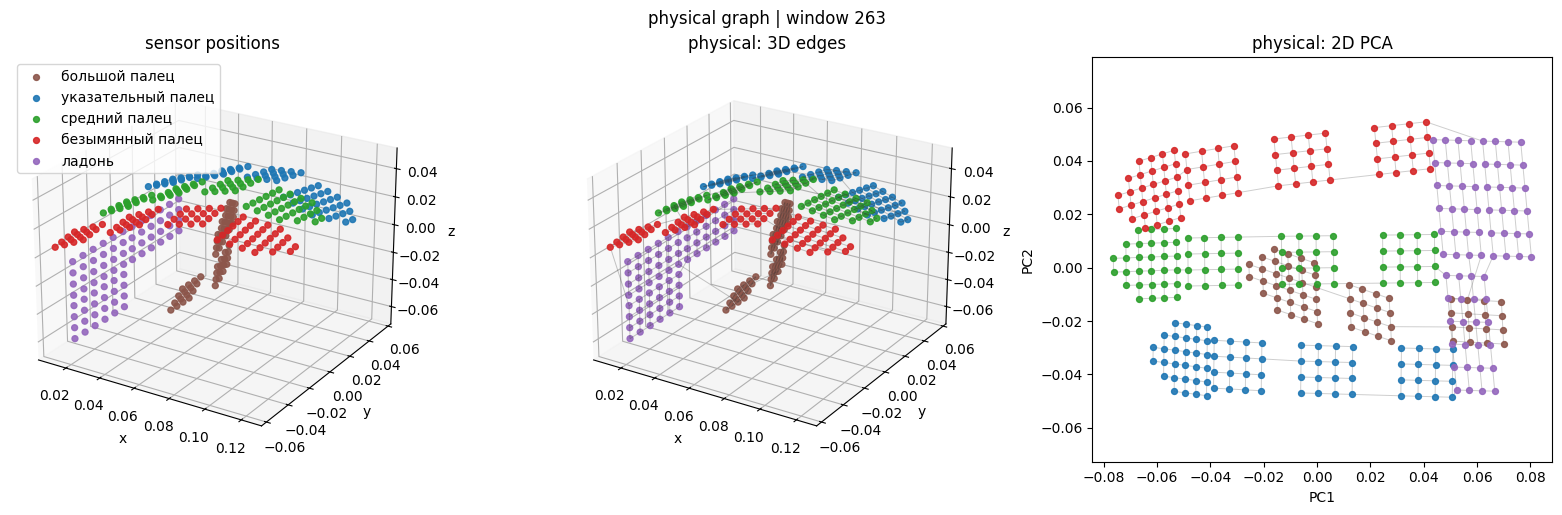

window=395 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 5, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.005166663788259029, 'mean_edge_weight': 0.006865501403808594, 'max_edge_weight': 0.049277015030384064}


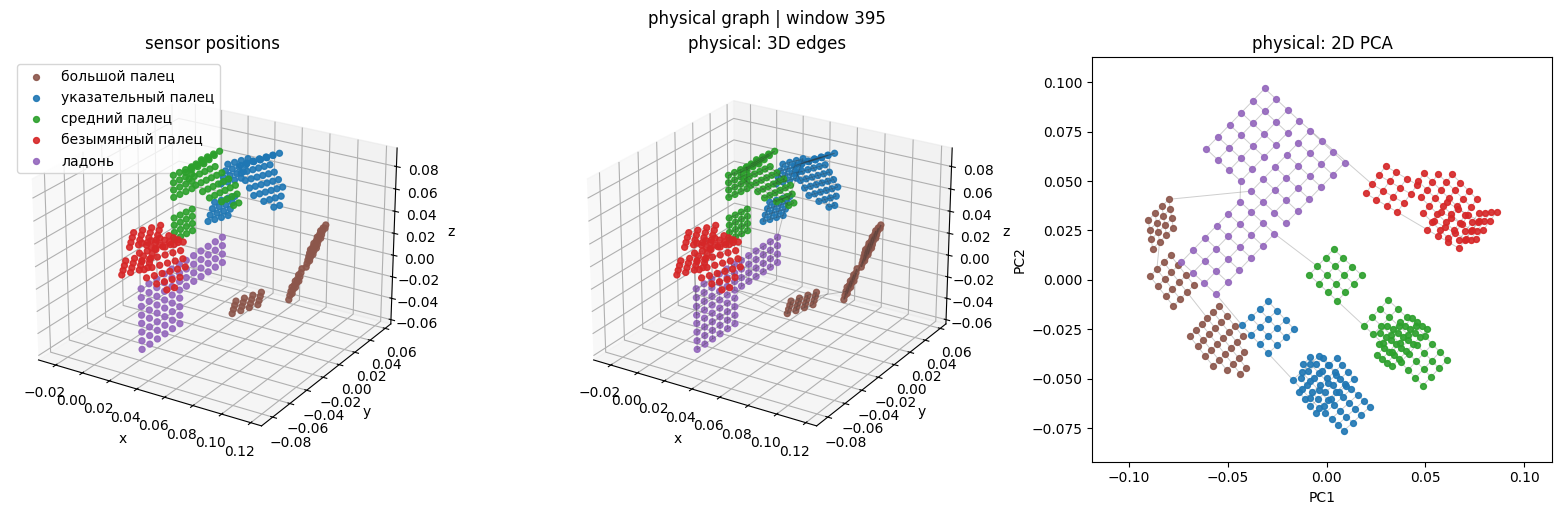

window=527 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 4, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.00516666192561388, 'mean_edge_weight': 0.006966460030525923, 'max_edge_weight': 0.05882631614804268}


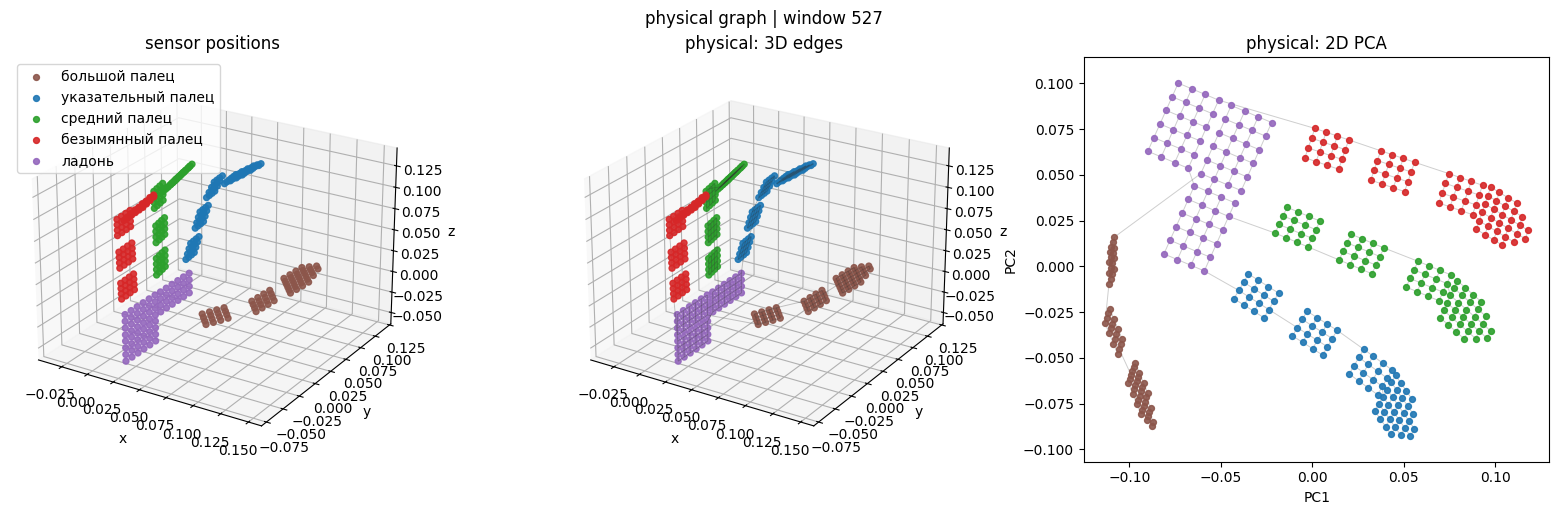

window=658 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 5, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.005166664719581604, 'mean_edge_weight': 0.006852906197309494, 'max_edge_weight': 0.044778112322092056}


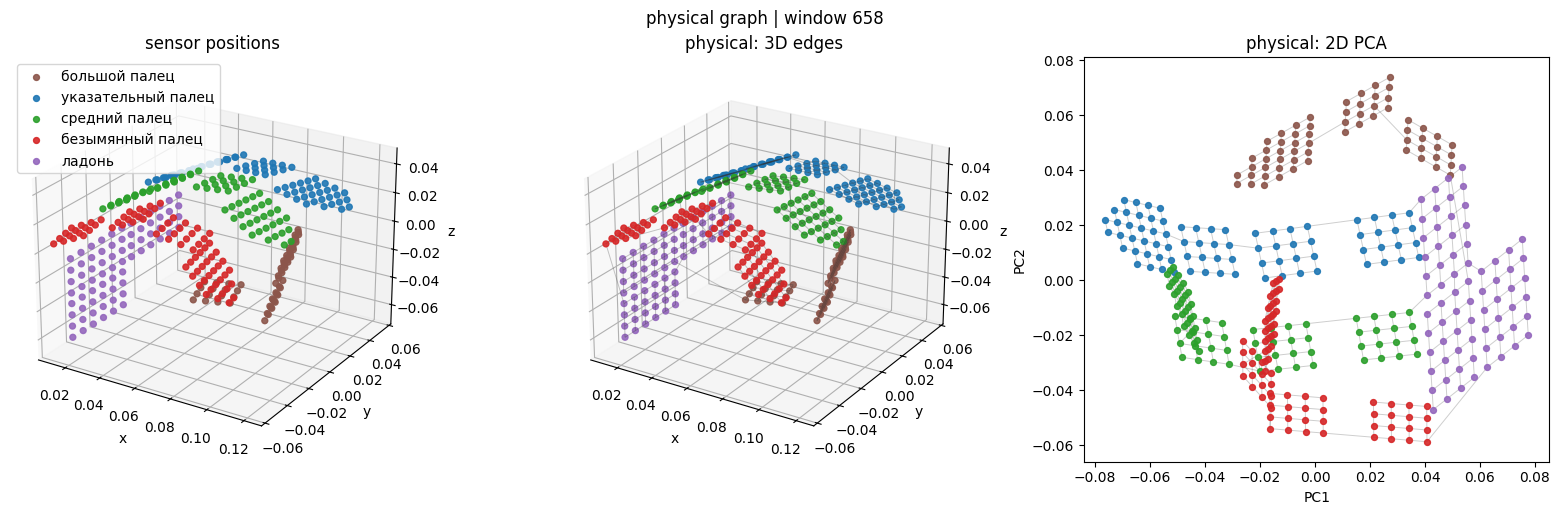

window=790 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 5, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.005166663322597742, 'mean_edge_weight': 0.00685914745554328, 'max_edge_weight': 0.04394270107150078}


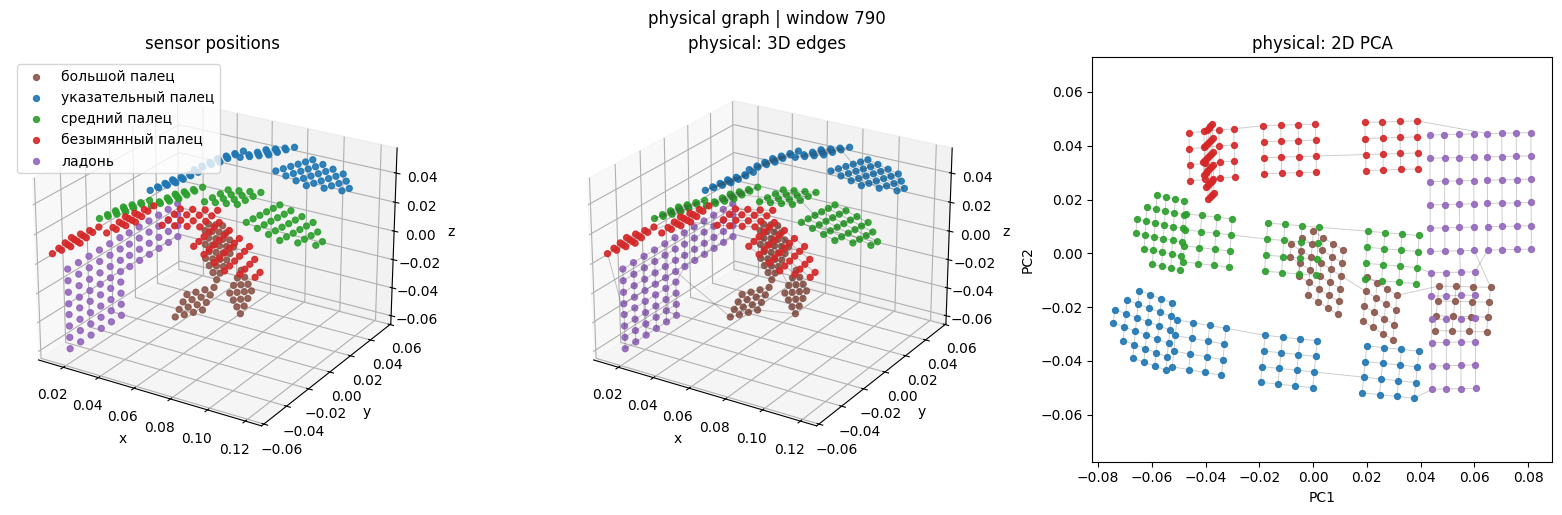

window=922 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 4, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.005166661459952593, 'mean_edge_weight': 0.006986481603235006, 'max_edge_weight': 0.07145575433969498}


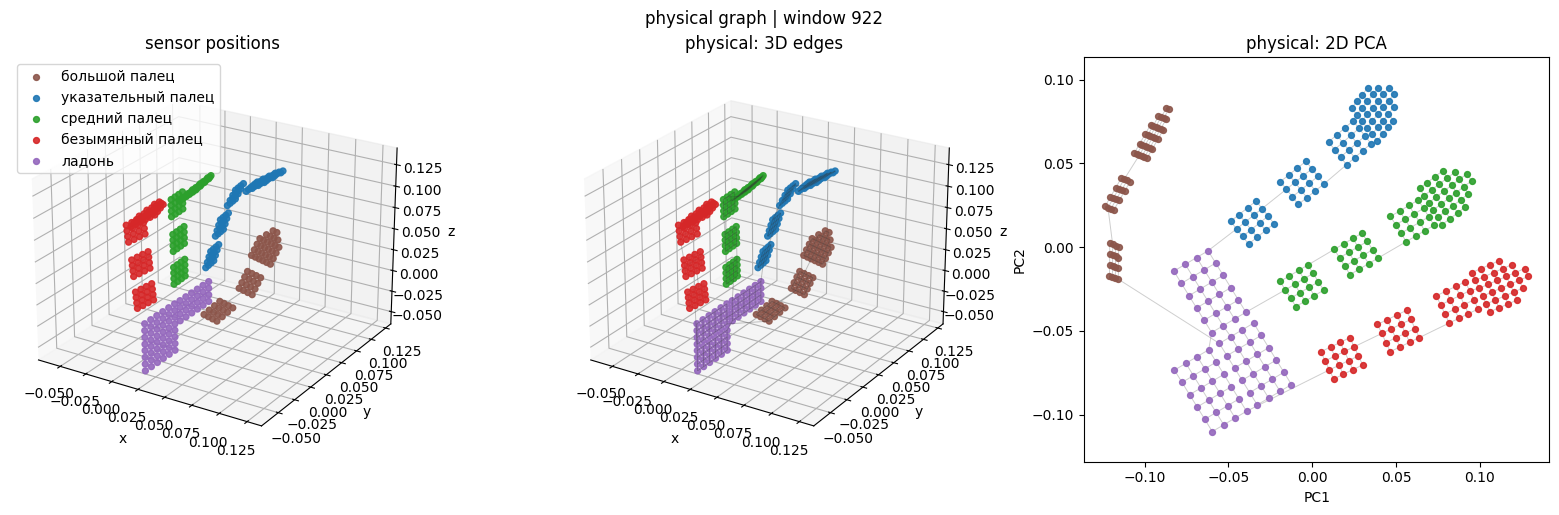

window=1054 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 4, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.005166662856936455, 'mean_edge_weight': 0.006950420793145895, 'max_edge_weight': 0.053733401000499725}


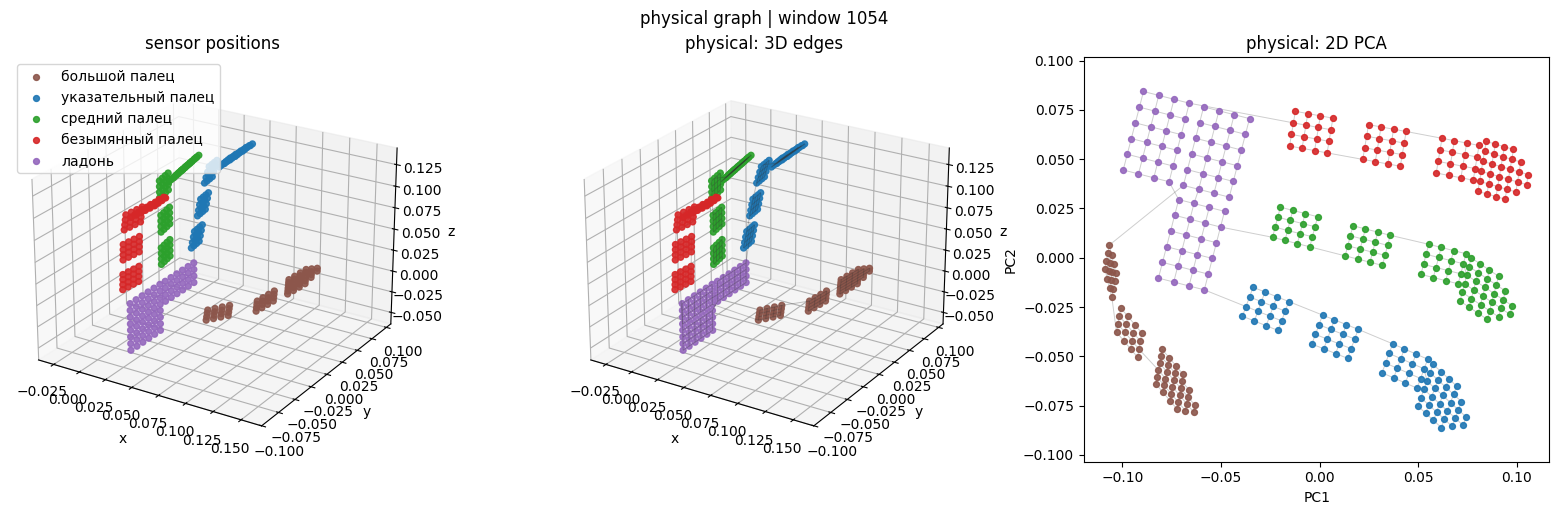

window=1186 {'num_nodes': 368, 'num_edges': 587, 'avg_degree': 3.1902173913043477, 'min_degree': 2, 'max_degree': 4, 'num_components': 1, 'largest_component': 368, 'min_edge_weight': 0.005166663788259029, 'mean_edge_weight': 0.006875650491565466, 'max_edge_weight': 0.047516319900751114}


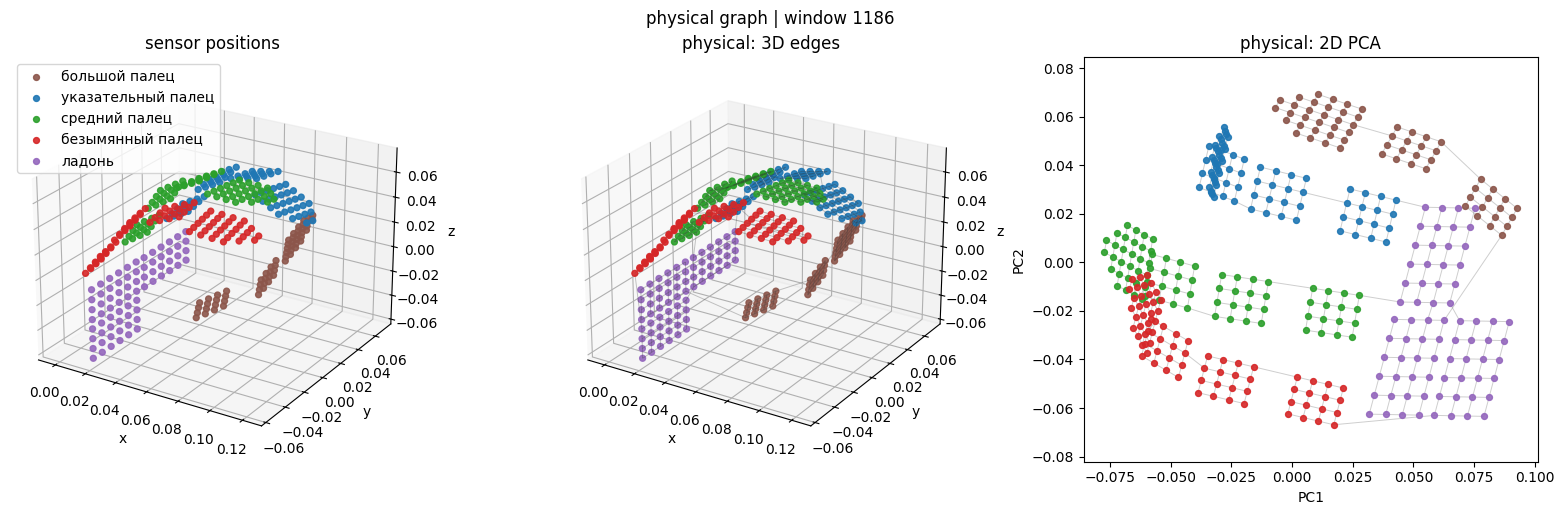

In [27]:
for window_id in VIS_WINDOW_IDS:
    positions = VIS_POSITIONS[window_id]
    graph = build_graph_by_type("physical", positions)
    print(f"window={window_id}", sensor_graph_stats(graph))
    fig = plot_sensor_graph_comparison(positions, graph)
    fig.suptitle(f"physical graph | window {window_id}", y=1.02)
    plt.show()


## Distance-threshold graph: 10 временных окон

Distance threshold: 0.020 m = 2.0 cm
window=0 {'num_nodes': 368, 'num_edges': 3152, 'avg_degree': 17.130434782608695, 'min_degree': 7, 'max_degree': 33, 'num_components': 3, 'largest_component': 306, 'min_edge_weight': 0.005166663322597742, 'mean_edge_weight': 0.012983650900423527, 'max_edge_weight': 0.019995614886283875}


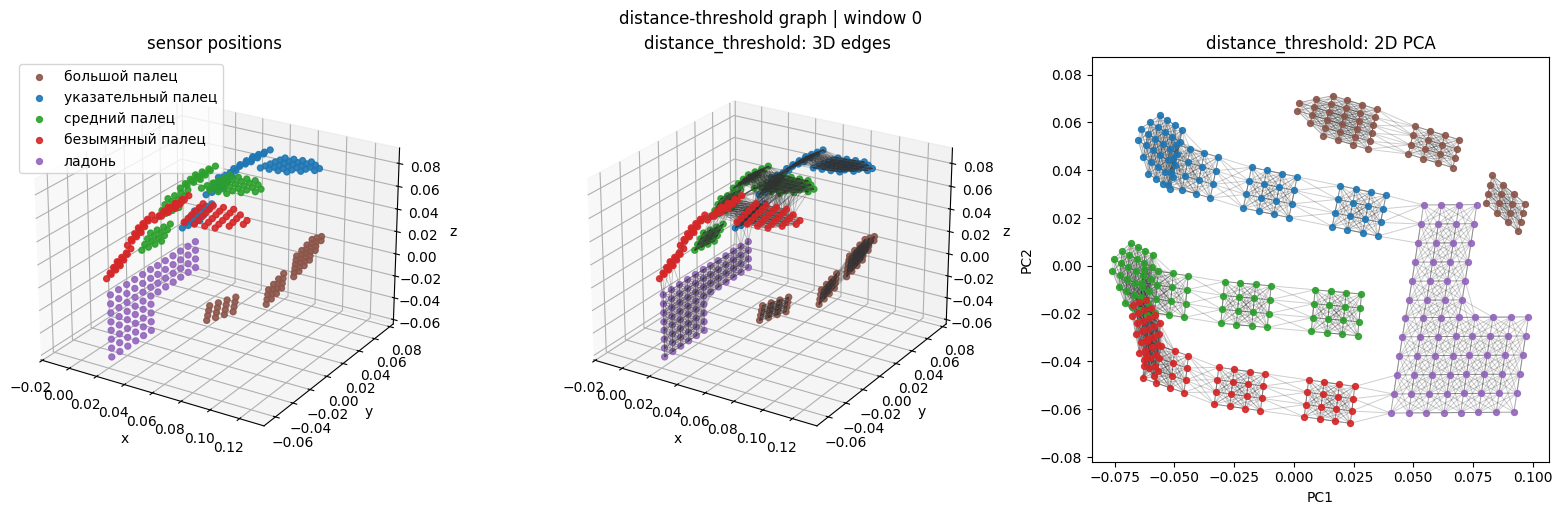

window=131 {'num_nodes': 368, 'num_edges': 2915, 'avg_degree': 15.842391304347826, 'min_degree': 7, 'max_degree': 27, 'num_components': 9, 'largest_component': 72, 'min_edge_weight': 0.00516665680333972, 'mean_edge_weight': 0.012701896019279957, 'max_edge_weight': 0.01992887817323208}


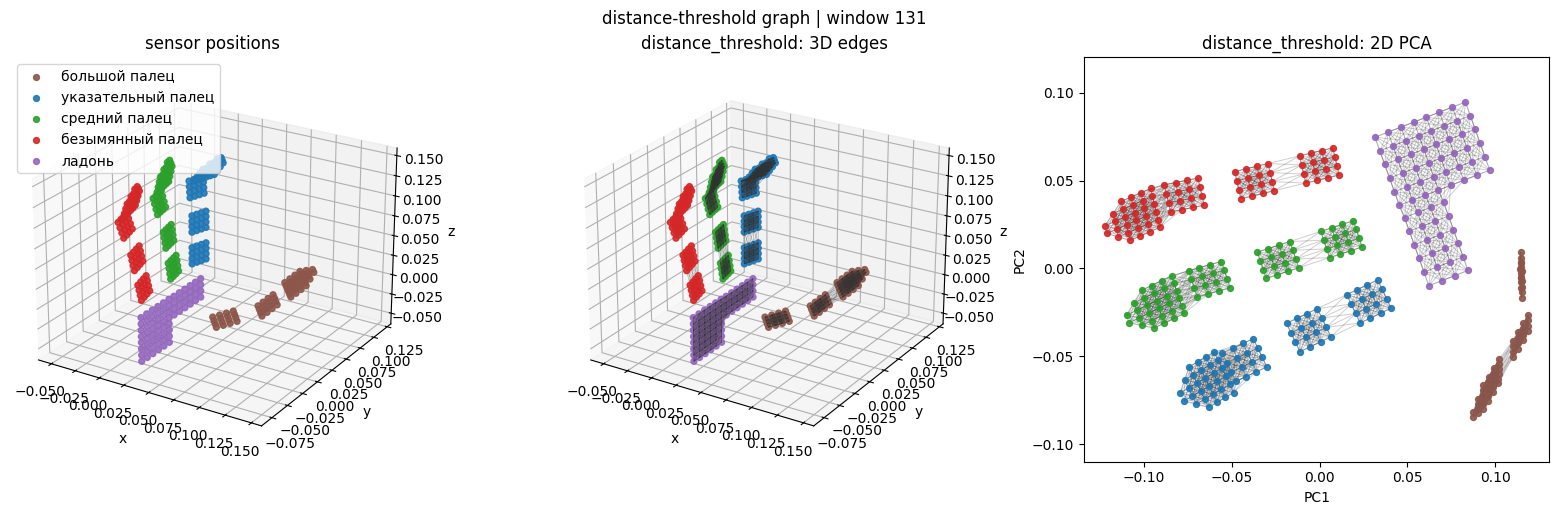

window=263 {'num_nodes': 368, 'num_edges': 3192, 'avg_degree': 17.347826086956523, 'min_degree': 7, 'max_degree': 34, 'num_components': 2, 'largest_component': 352, 'min_edge_weight': 0.005166663788259029, 'mean_edge_weight': 0.013003690168261528, 'max_edge_weight': 0.019982224330306053}


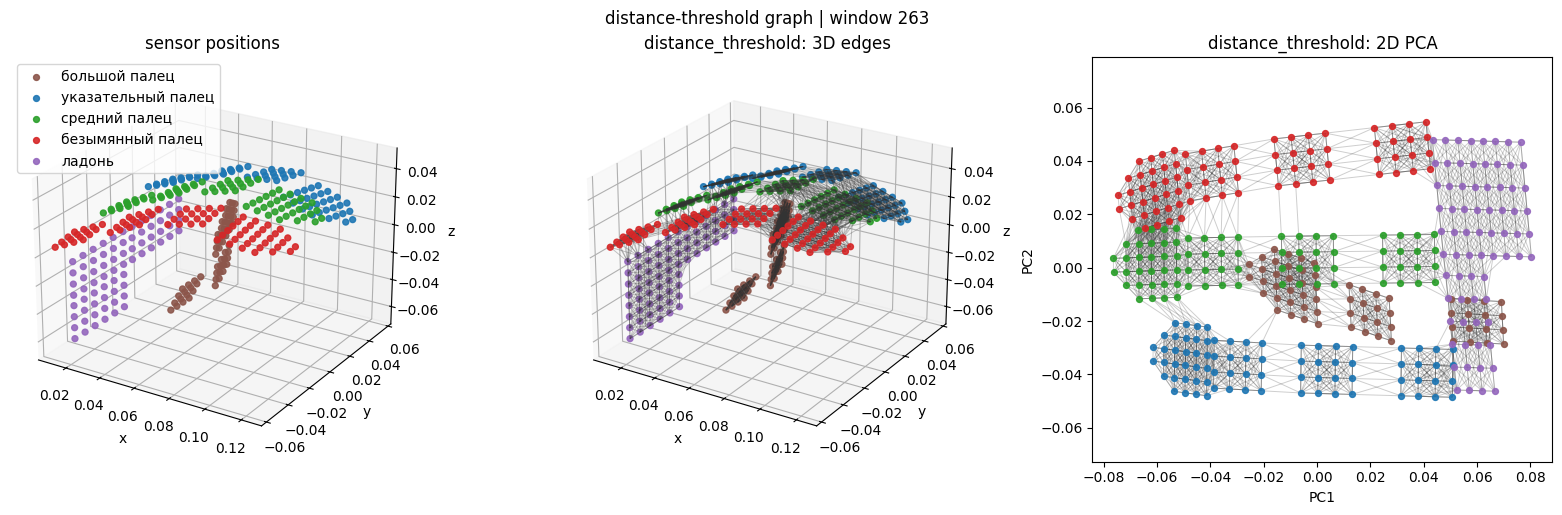

window=395 {'num_nodes': 368, 'num_edges': 3427, 'avg_degree': 18.625, 'min_degree': 7, 'max_degree': 39, 'num_components': 4, 'largest_component': 156, 'min_edge_weight': 0.005166663788259029, 'mean_edge_weight': 0.013100783340632915, 'max_edge_weight': 0.01999158412218094}


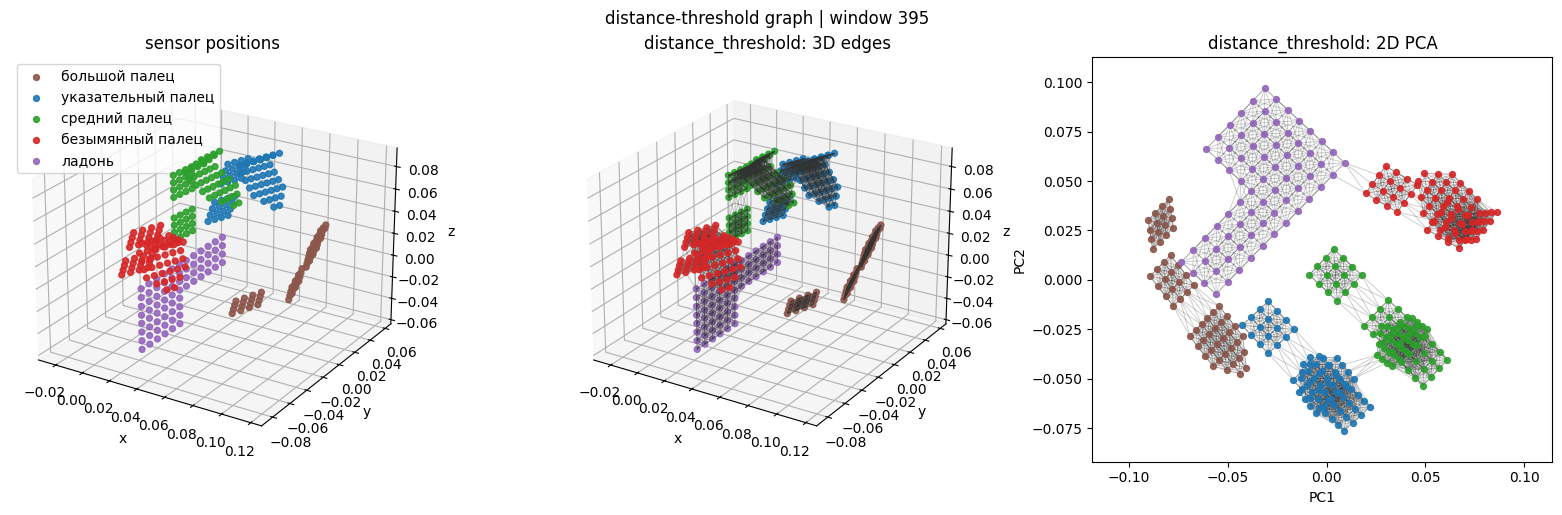

window=527 {'num_nodes': 368, 'num_edges': 2947, 'avg_degree': 16.016304347826086, 'min_degree': 7, 'max_degree': 27, 'num_components': 7, 'largest_component': 78, 'min_edge_weight': 0.00516666192561388, 'mean_edge_weight': 0.012731908820569515, 'max_edge_weight': 0.019941670820116997}


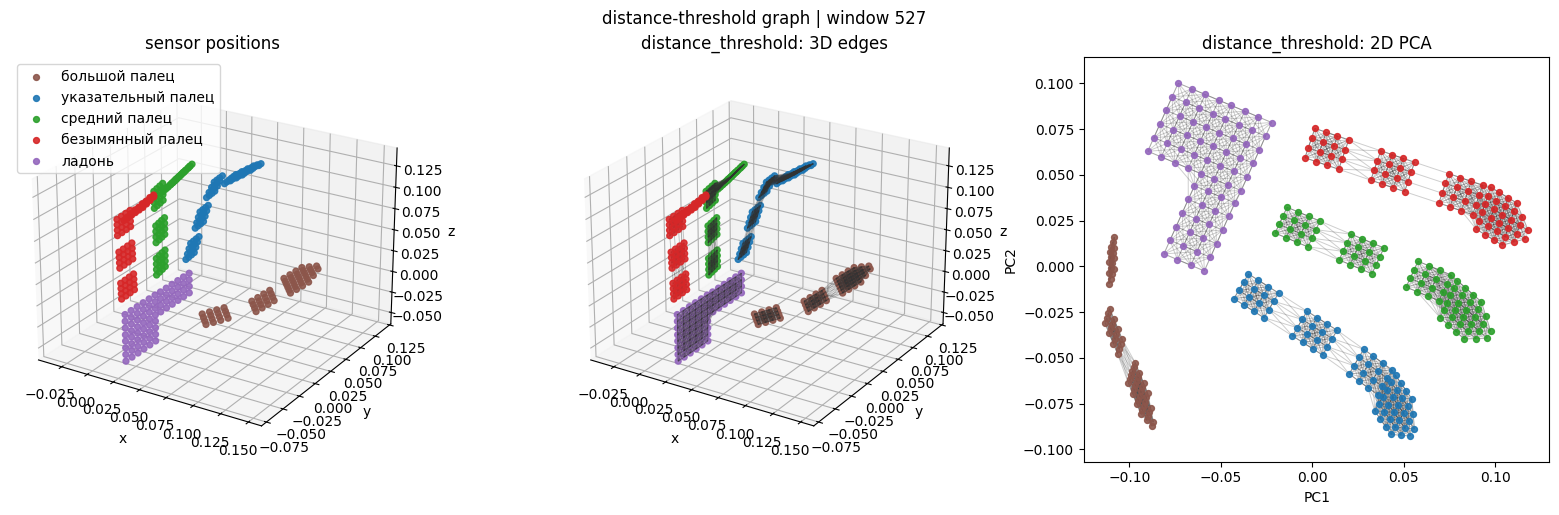

window=658 {'num_nodes': 368, 'num_edges': 3201, 'avg_degree': 17.39673913043478, 'min_degree': 7, 'max_degree': 32, 'num_components': 2, 'largest_component': 306, 'min_edge_weight': 0.005166664719581604, 'mean_edge_weight': 0.013057338073849678, 'max_edge_weight': 0.019994566217064857}


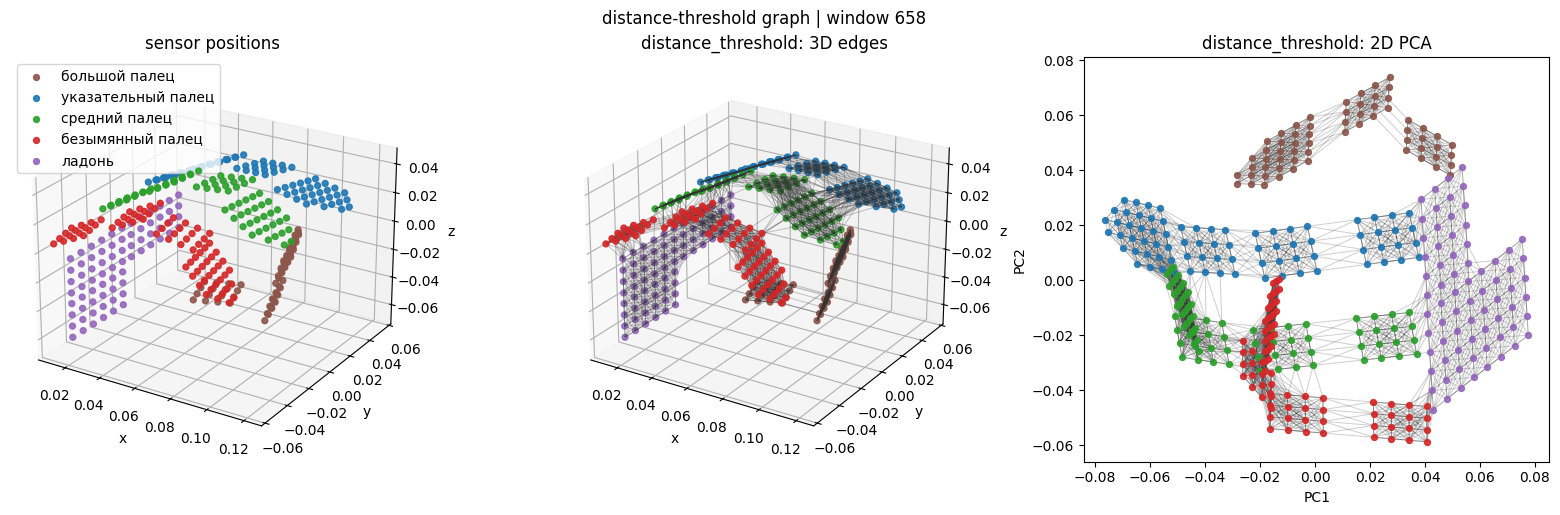

window=790 {'num_nodes': 368, 'num_edges': 3191, 'avg_degree': 17.342391304347824, 'min_degree': 7, 'max_degree': 33, 'num_components': 2, 'largest_component': 306, 'min_edge_weight': 0.005166663322597742, 'mean_edge_weight': 0.01304926723241806, 'max_edge_weight': 0.01997707597911358}


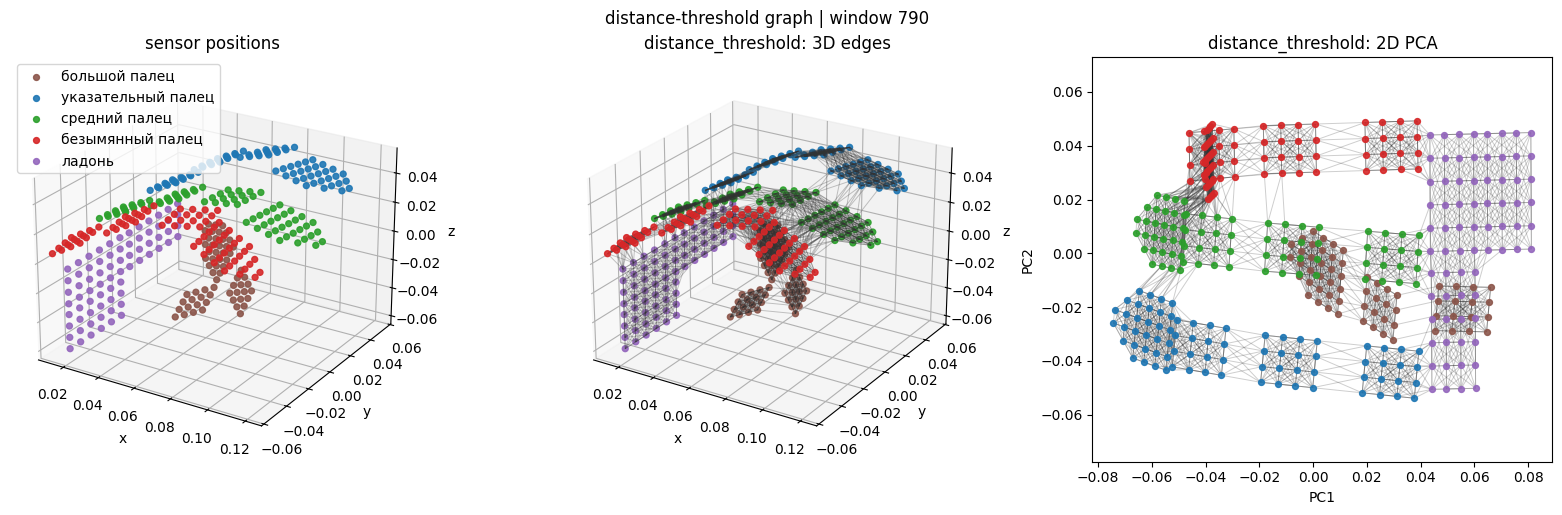

window=922 {'num_nodes': 368, 'num_edges': 2957, 'avg_degree': 16.070652173913043, 'min_degree': 7, 'max_degree': 28, 'num_components': 7, 'largest_component': 78, 'min_edge_weight': 0.005166661459952593, 'mean_edge_weight': 0.012748673558235168, 'max_edge_weight': 0.01998920552432537}


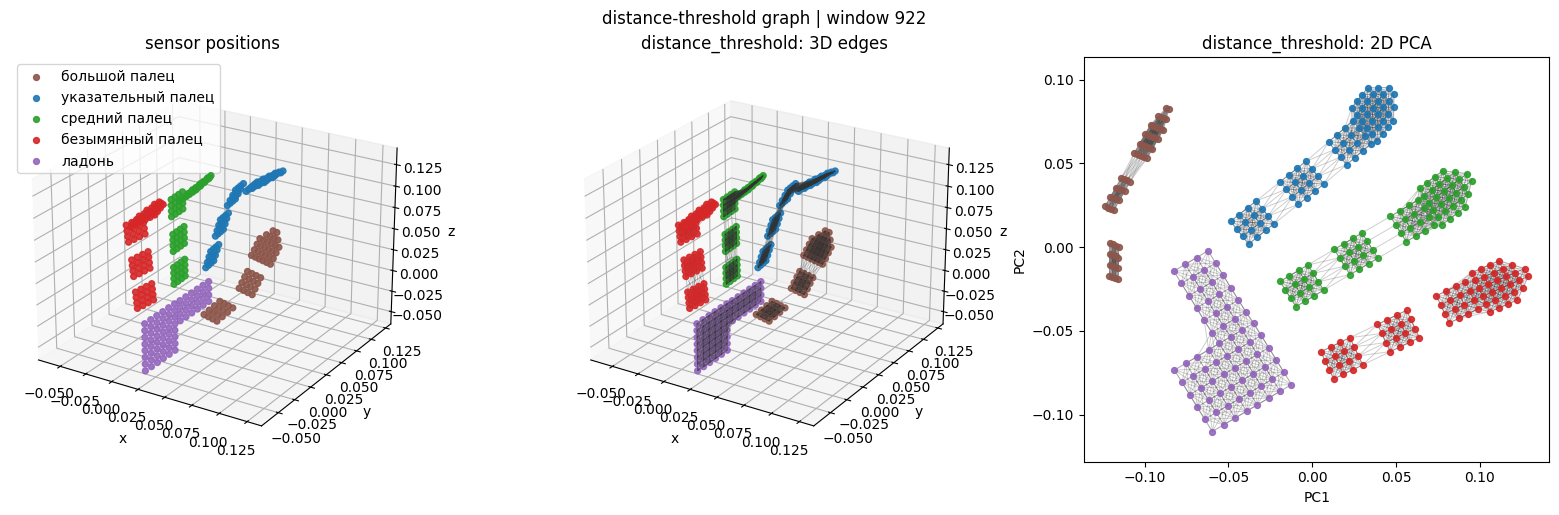

window=1054 {'num_nodes': 368, 'num_edges': 2957, 'avg_degree': 16.070652173913043, 'min_degree': 7, 'max_degree': 28, 'num_components': 7, 'largest_component': 78, 'min_edge_weight': 0.005166662856936455, 'mean_edge_weight': 0.012753326445817947, 'max_edge_weight': 0.01993311196565628}


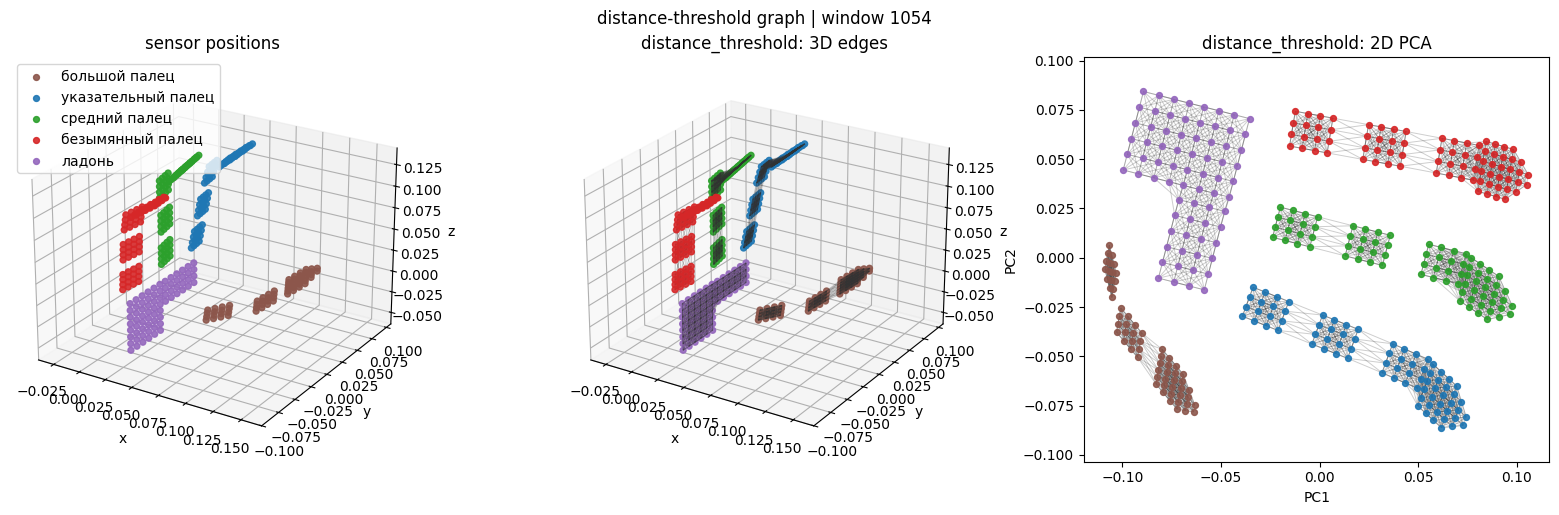

window=1186 {'num_nodes': 368, 'num_edges': 3195, 'avg_degree': 17.36413043478261, 'min_degree': 7, 'max_degree': 33, 'num_components': 3, 'largest_component': 306, 'min_edge_weight': 0.005166663788259029, 'mean_edge_weight': 0.013047385029494762, 'max_edge_weight': 0.019987042993307114}


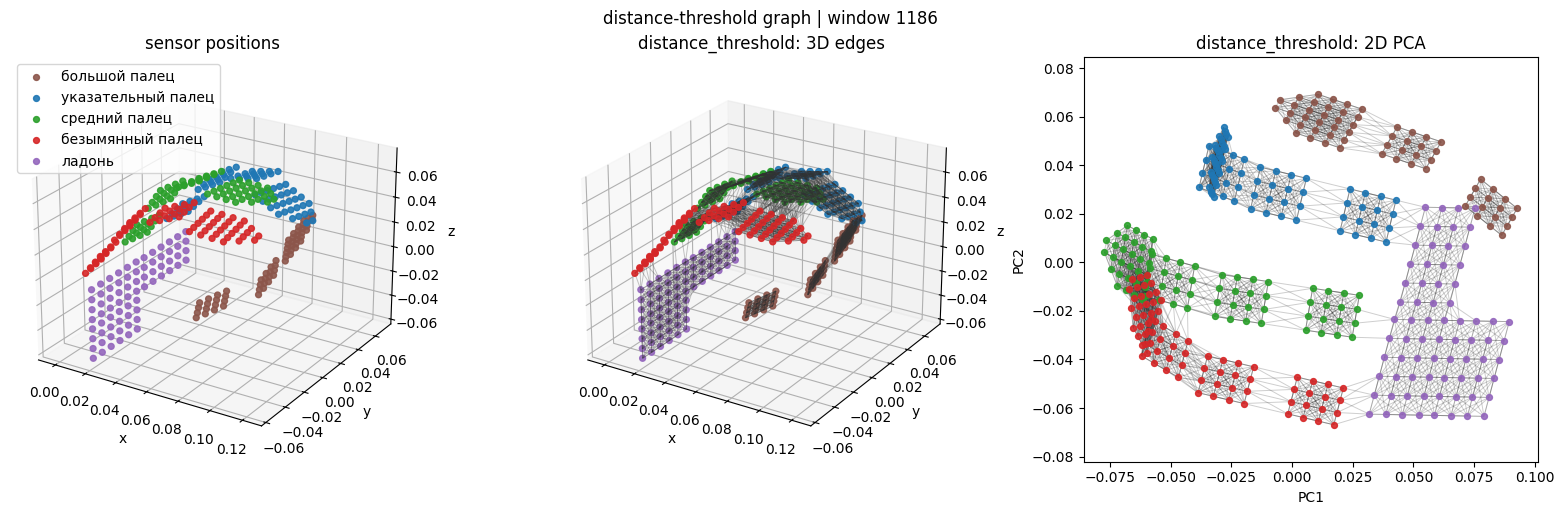

In [28]:
print(f"Distance threshold: {DISTANCE_THRESHOLD:.3f} m = {DISTANCE_THRESHOLD * 100:.1f} cm")
for window_id in VIS_WINDOW_IDS:
    positions = VIS_POSITIONS[window_id]
    graph = build_graph_by_type("distance_threshold", positions)
    print(f"window={window_id}", sensor_graph_stats(graph))
    fig = plot_sensor_graph_comparison(positions, graph)
    fig.suptitle(f"distance-threshold graph | window {window_id}", y=1.02)
    plt.show()


## Distance-threshold sweep on representative window

For the distance-based graph, compute the mean pairwise sensor distance `s` on window `DISTANCE_SWEEP_WINDOW_ID`, then sweep thresholds from `0.5s` to `10s`. Each row reports whether the graph is connected, and the plots below show how edge count changes with the threshold and how each graph looks on the same window.


In [ ]:
sweep_window_id = min(DISTANCE_SWEEP_WINDOW_ID, len(dataset) - 1)
sweep_positions = get_window_positions(sweep_window_id)

distance_matrix = pairwise_sensor_distances(sweep_positions)
pair_i, pair_j = np.triu_indices_from(distance_matrix, k=1)
s = float(distance_matrix[pair_i, pair_j].mean())

threshold_multipliers = np.arange(
    DISTANCE_SWEEP_STEP_MULTIPLIER,
    DISTANCE_SWEEP_MAX_MULTIPLIER + 1e-9,
    DISTANCE_SWEEP_STEP_MULTIPLIER,
)

threshold_sweep_rows = []
for multiplier in threshold_multipliers:
    threshold = float(multiplier * s)
    graph = build_distance_threshold_graph(sweep_positions, threshold=threshold)
    row = sensor_graph_stats(graph)
    row.update(
        {
            "threshold_multiplier": float(multiplier),
            "threshold_m": threshold,
            "threshold_cm": threshold * 100.0,
            "connected": row["num_components"] == 1,
        }
    )
    threshold_sweep_rows.append(row)

threshold_sweep_df = pd.DataFrame(threshold_sweep_rows)
connected_multipliers = threshold_sweep_df.loc[
    threshold_sweep_df["connected"], "threshold_multiplier"
].tolist()

print(f"window_id: {sweep_window_id}")
print(f"s = mean pairwise sensor distance: {s:.6f} m = {s * 100.0:.3f} cm")
print(
    "Connected threshold multipliers: "
    + (", ".join(f"{value:.1f}s" for value in connected_multipliers) if connected_multipliers else "none")
)

threshold_sweep_df[
    [
        "threshold_multiplier",
        "threshold_m",
        "threshold_cm",
        "num_edges",
        "num_components",
        "largest_component",
        "mean_edge_weight",
        "avg_degree",
        "min_degree",
        "max_degree",
        "connected",
    ]
]


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
x = threshold_sweep_df["threshold_multiplier"]

plot_specs = [
    (axes[0, 0], "num_edges", "num_edges", "tab:blue"),
    (axes[0, 1], "num_components", "num_components", "tab:red"),
    (axes[1, 0], "mean_edge_weight", "mean edge weight, m", "tab:orange"),
    (axes[1, 1], "avg_degree", "avg vertex degree", "tab:purple"),
]

for ax, column, ylabel, color in plot_specs:
    ax.plot(x, threshold_sweep_df[column], marker="o", linewidth=2, color=color)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    for multiplier in threshold_sweep_df.loc[threshold_sweep_df["connected"], "threshold_multiplier"]:
        ax.axvline(multiplier, color="tab:green", alpha=0.12, linewidth=8)

for ax in axes[-1, :]:
    ax.set_xlabel("distance threshold / s")

fig.suptitle(f"Distance-threshold sweep on window {sweep_window_id}; s={s:.4f} m")
fig.tight_layout()
plt.show()


In [ ]:
for _, row in threshold_sweep_df.iterrows():
    multiplier = float(row["threshold_multiplier"])
    threshold_m = float(row["threshold_m"])
    threshold_cm = float(row["threshold_cm"])
    num_edges = int(row["num_edges"])
    num_components = int(row["num_components"])
    connected = bool(row["connected"])

    graph = build_distance_threshold_graph(sweep_positions, threshold=threshold_m)
    print(
        f"threshold={multiplier:.1f}s ({threshold_m:.6f} m, {threshold_cm:.3f} cm): "
        f"edges={num_edges}; components={num_components}; connected={connected}"
    )
    fig = plot_sensor_graph_comparison(sweep_positions, graph)
    fig.suptitle(
        f"Distance-threshold graph, window {sweep_window_id}, threshold={multiplier:.1f}s",
        y=1.02,
    )
    plt.show()


## KNN sweep on representative window

For the pad-local k-nearest-neighbor graph, sweep `k_inner_neighbors` from `K_SWEEP_MIN` to `K_SWEEP_MAX` on the same representative window. The table marks connected graphs, and the plots track edge count, connected components, mean edge weight, and average vertex degree.


In [ ]:
knn_sweep_window_id = min(K_SWEEP_WINDOW_ID, len(dataset) - 1)
knn_sweep_positions = get_window_positions(knn_sweep_window_id)
knn_values = list(range(K_SWEEP_MIN, K_SWEEP_MAX + 1))

knn_sweep_rows = []
for k_inner_neighbors in knn_values:
    graph = build_knn_graph(
        knn_sweep_positions,
        k_inner_neighbors=k_inner_neighbors,
        k_outer_neighbors=K_OUTER_NEIGHBORS,
        symmetrize=True,
    )
    row = sensor_graph_stats(graph)
    row.update(
        {
            "k_inner_neighbors": int(k_inner_neighbors),
            "k_outer_neighbors": int(K_OUTER_NEIGHBORS),
            "connected": row["num_components"] == 1,
        }
    )
    knn_sweep_rows.append(row)

knn_sweep_df = pd.DataFrame(knn_sweep_rows)
connected_k_values = knn_sweep_df.loc[knn_sweep_df["connected"], "k_inner_neighbors"].tolist()

print(f"window_id: {knn_sweep_window_id}")
print(f"fixed k_outer_neighbors: {K_OUTER_NEIGHBORS}")
print(
    "Connected k_inner values: "
    + (", ".join(str(value) for value in connected_k_values) if connected_k_values else "none")
)

knn_sweep_df[
    [
        "k_inner_neighbors",
        "k_outer_neighbors",
        "num_edges",
        "num_components",
        "largest_component",
        "mean_edge_weight",
        "avg_degree",
        "min_degree",
        "max_degree",
        "connected",
    ]
]


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
x = knn_sweep_df["k_inner_neighbors"]

plot_specs = [
    (axes[0, 0], "num_edges", "num_edges", "tab:blue"),
    (axes[0, 1], "num_components", "num_components", "tab:red"),
    (axes[1, 0], "mean_edge_weight", "mean edge weight, m", "tab:orange"),
    (axes[1, 1], "avg_degree", "avg vertex degree", "tab:purple"),
]

for ax, column, ylabel, color in plot_specs:
    ax.plot(x, knn_sweep_df[column], marker="o", linewidth=2, color=color)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    for k_inner_neighbors in knn_sweep_df.loc[knn_sweep_df["connected"], "k_inner_neighbors"]:
        ax.axvline(k_inner_neighbors, color="tab:green", alpha=0.12, linewidth=8)

for ax in axes[-1, :]:
    ax.set_xlabel("k inner neighbors")
    ax.set_xticks(knn_values)

fig.suptitle(
    f"KNN sweep on window {knn_sweep_window_id}; fixed k_outer={K_OUTER_NEIGHBORS}"
)
fig.tight_layout()
plt.show()


In [ ]:
for _, row in knn_sweep_df.iterrows():
    k_inner_neighbors = int(row["k_inner_neighbors"])
    num_edges = int(row["num_edges"])
    num_components = int(row["num_components"])
    connected = bool(row["connected"])

    graph = build_knn_graph(
        knn_sweep_positions,
        k_inner_neighbors=k_inner_neighbors,
        k_outer_neighbors=K_OUTER_NEIGHBORS,
        symmetrize=True,
    )
    print(
        f"k_inner={k_inner_neighbors}, k_outer={K_OUTER_NEIGHBORS}: "
        f"edges={num_edges}; components={num_components}; connected={connected}"
    )
    fig = plot_sensor_graph_comparison(knn_sweep_positions, graph)
    fig.suptitle(
        f"KNN graph, window {knn_sweep_window_id}, "
        f"k_inner={k_inner_neighbors}, k_outer={K_OUTER_NEIGHBORS}",
        y=1.02,
    )
    plt.show()


## Custom graph: 10 временных окон

In [ ]:
print(
    "custom graph parameters: "
    f"link_pads={CUSTOM_LINK_PADS}, "
    f"phys_bridge_k={CUSTOM_PHYS_BRIDGE_K}, "
    f"distance_threshold={CUSTOM_DISTANCE_THRESHOLD}, "
    f"k_inner_neighbors={CUSTOM_K_INNER_NEIGHBORS}, "
    f"k_outer_neighbors={CUSTOM_K_OUTER_NEIGHBORS}, "
    f"outer_edge_distance={CUSTOM_OUTER_EDGE_DISTANCE}"
)
for window_id in VIS_WINDOW_IDS:
    positions = VIS_POSITIONS[window_id]
    graph = build_graph_by_type("custom", positions)
    print(f"window={window_id}", sensor_graph_stats(graph))
    fig = plot_sensor_graph_comparison(positions, graph)
    fig.suptitle(f"custom graph | window {window_id}", y=1.02)
    plt.show()


## kNN graph: 10 временных окон

In [ ]:
print(f"k inner neighbors: {K_INNER_NEIGHBORS}")
print(f"k outer neighbors: {K_OUTER_NEIGHBORS}")
for window_id in VIS_WINDOW_IDS:
    positions = VIS_POSITIONS[window_id]
    graph = build_graph_by_type("knn", positions)
    print(f"window={window_id}", sensor_graph_stats(graph))
    fig = plot_sensor_graph_comparison(positions, graph)
    fig.suptitle(f"kNN graph | window {window_id}", y=1.02)
    plt.show()
